Absolutely! SHAP (SHapley Additive exPlanations) is a powerful and versatile method for interpreting machine learning models. It provides insights into how each feature contributes to the model's predictions, making it easier to understand and trust complex models like neural networks, gradient boosting machines, or even simple linear models.

---

### **What is SHAP?**

SHAP is based on **Shapley values**, a concept from cooperative game theory. Shapley values aim to fairly distribute the "contribution" of each player (in this case, each feature) in a game (the prediction). In the context of machine learning:
- Each feature is treated as a "player."
- The prediction is treated as the "game outcome."
- SHAP calculates how much each feature contributes to the difference between the actual prediction and the average prediction.

The key idea is that SHAP assigns an importance value to each feature for every individual prediction, ensuring consistency and fairness.

---

### **Why Use SHAP?**

1. **Model-Agnostic**: SHAP works with any machine learning model, regardless of complexity.
2. **Local and Global Interpretability**: You can interpret individual predictions (local) or understand overall feature importance across the dataset (global).
3. **Fair Attribution**: SHAP ensures that the contributions of features are consistent and additive, adhering to theoretical guarantees from game theory.
4. **Visualization**: SHAP provides intuitive visualizations to communicate insights effectively.

---

### **How Does SHAP Work?**

#### **Step 1: Shapley Values**
Shapley values calculate the contribution of each feature by considering all possible combinations of features. For a given prediction, the Shapley value of a feature is the average marginal contribution of that feature across all possible coalitions of features.

Mathematically:
$$
\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F| - |S| - 1)!}{|F|!} \big[ f(S \cup \{i\}) - f(S) \big]
$$
Where:
- $ F $: Set of all features.
- $ S $: Subset of features excluding feature $ i $.
- $ f(S) $: Prediction made using features in subset $ S $.

#### **Step 2: Efficient Approximation**
Calculating exact Shapley values is computationally expensive because it involves evaluating all possible subsets of features. SHAP uses approximations tailored to specific types of models:
- **TreeExplainer**: Optimized for tree-based models (e.g., XGBoost, LightGBM, Random Forests).
- **DeepExplainer**: Designed for deep learning models.
- **KernelExplainer**: A general-purpose explainer for any model, but slower.

---

### **Key SHAP Outputs**

1. **Feature Importance**: Global view of which features contribute most to the model's predictions.
2. **SHAP Values**: Local contribution of each feature to a specific prediction.
3. **Summary Plot**: Combines global and local insights to show feature distributions and their impact.
4. **Dependence Plot**: Shows how a single feature affects predictions, including interactions with other features.
5. **Force Plot**: Visualizes how individual features push the prediction higher or lower compared to the base value.

---

### **Hands-On Example**

Let’s walk through an example using Python and the `shap` library.

#### **Step 1: Install and Import Libraries**
```bash
pip install shap
```

```python
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_boston
```

#### **Step 2: Load Data**
For simplicity, we’ll use the Boston Housing dataset (note: this dataset is deprecated in newer versions of scikit-learn, so you may need to use an alternative).

```python
# Load dataset
data = load_boston()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

#### **Step 3: Train a Model**
We’ll use XGBoost for this example.

```python
# Train an XGBoost model
model = xgb.XGBRegressor()
model.fit(X_train, y_train)
```

#### **Step 4: Initialize SHAP Explainer**
Use the `TreeExplainer` since we’re working with a tree-based model.

```python
# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
```

#### **Step 5: Visualize Results**

1. **Summary Plot** (Global Feature Importance):
```python
shap.summary_plot(shap_values, X_test, feature_names=data.feature_names)
```
This plot shows the top features and their impact on predictions, highlighting both magnitude and direction.

2. **Dependence Plot** (Feature Interaction):
```python
shap.dependence_plot("RM", shap_values, X_test, feature_names=data.feature_names)
```
This plot shows how the feature `RM` (average number of rooms per dwelling) affects predictions, along with potential interactions with other features.

3. **Force Plot** (Local Explanation):
```python
shap.force_plot(explainer.expected_value, shap_values[0, :], X_test[0, :], feature_names=data.feature_names)
```
This plot explains a single prediction, showing how each feature pushes the prediction higher or lower.

---

### **Key Insights from SHAP**

1. **Positive/Negative Contributions**: Features with positive SHAP values increase the prediction, while negative values decrease it.
2. **Interactions**: SHAP can reveal how features interact with each other to influence predictions.
3. **Base Value**: The expected value of the model output (average prediction) serves as the starting point for explanations.

---

### **When to Use SHAP**

- **Debugging Models**: Identify why a model makes incorrect predictions.
- **Communicating Insights**: Explain predictions to stakeholders in a clear and interpretable way.
- **Fairness Audits**: Detect bias in model predictions by analyzing feature contributions.
- **Feature Selection**: Focus on the most impactful features for model simplification.

---

### **Limitations of SHAP**

1. **Computational Cost**: Exact Shapley values are expensive to compute for large datasets or complex models.
2. **Interpretability Assumptions**: SHAP assumes that features are independent when calculating contributions, which may not always hold.
3. **Visualization Overload**: With many features, SHAP plots can become cluttered and harder to interpret.

---

### **Conclusion**

SHAP is a robust and theoretically grounded tool for interpreting machine learning models. By providing both local and global insights, it bridges the gap between model complexity and interpretability. Whether you're debugging a model, explaining predictions to non-technical stakeholders, or auditing for fairness, SHAP is an invaluable tool in your ML toolkit.



In [5]:
pip install shap scikit-learn matplotlib

In [6]:
import shap
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load the Iris dataset
data = load_iris()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature names for interpretability
feature_names = data.feature_names

In [7]:
# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

<Figure size 640x480 with 0 Axes>

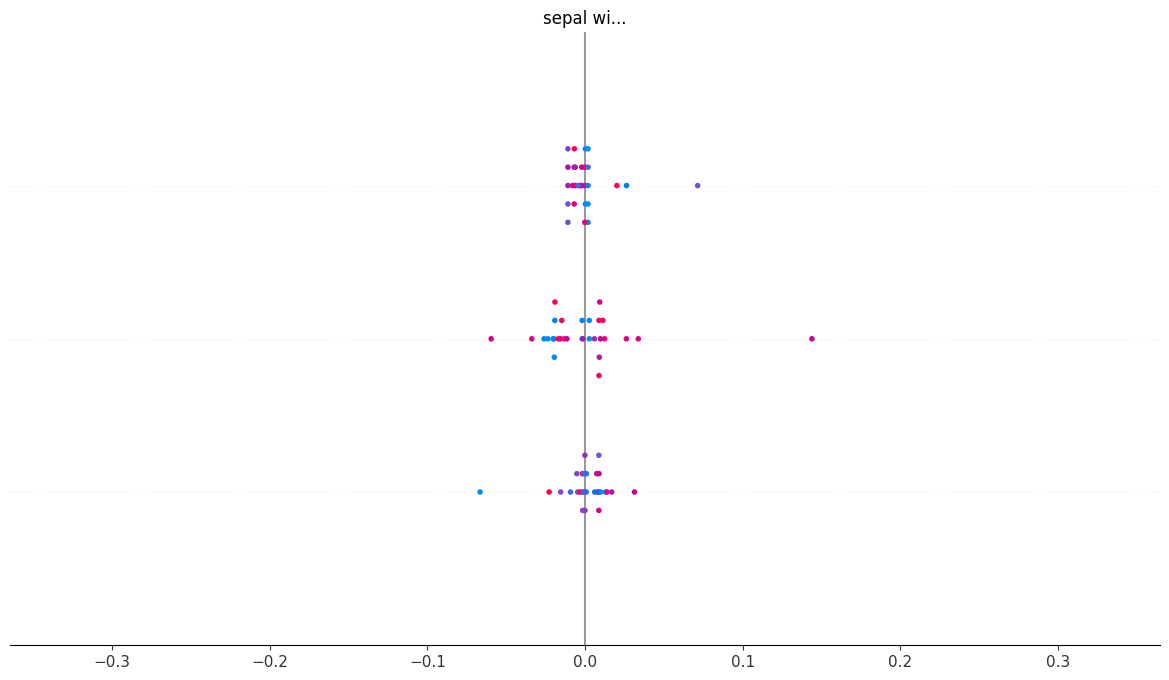

In [11]:
# Visualize the summary plot
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

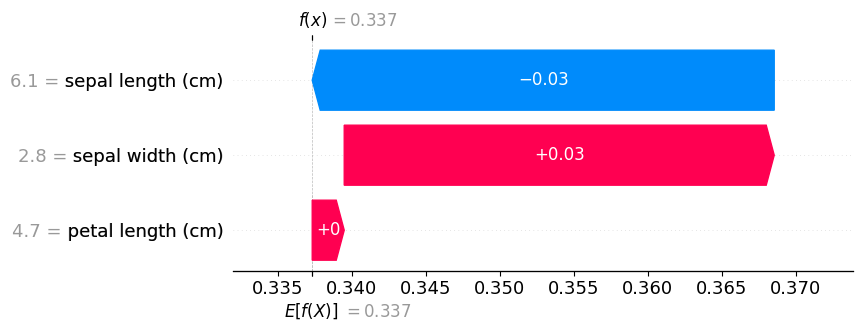

In [13]:
# Visualize the waterfall plot for the first prediction
shap.waterfall_plot(shap.Explanation(values=shap_values[0][0], base_values=explainer.expected_value[0], data=X_test[0], feature_names=feature_names))

What You’ll See
Force Plot : A tug-of-war visualization showing how each feature pushes the prediction higher or lower.

Summary Plot : A beeswarm plot ranking features by importance and showing their impact on predictions.

Dependence Plot : A scatter plot showing the effect of "petal length" on predictions, with potential interactions.

Waterfall Plot : A stacked bar chart breaking down a single prediction into feature contributions.

##Key Takeaways
SHAP provides both local explanations (e.g., force plot, waterfall plot) and global insights (e.g., summary plot).

It works seamlessly with models like Random Forests via TreeExplainer.

The Iris dataset is small and simple, making it ideal for learning SHAP. For larger datasets, you may need to optimize computation (e.g., subsampling data).

